In [1]:
from pathlib import Path

OBJECT = "2_squares"
# "catalyst"
# "circle"
# "2_squares"

# CONFIG
PROJECT_FOLDER = Path(r"C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw")
SINOGRAM_FILE = Path(rf"C:\Users\Alberto\Desktop\Electron tomography\datasets\{OBJECT}\sinograms\sinogram_-50_5_50.mrc")
DATA_DIR = PROJECT_FOLDER / "data"
DATA_DIR.mkdir(exist_ok=True)

# The target file for our single high-quality FBP reconstruction
FULL_FBP_FILE = DATA_DIR / "full_slice_fbp.mrc"

FROM = -50
TO = 50
STEP = 5

## STEP 1 - SPLITTING TILT SERIES

In [2]:
FBP = False

In [3]:
## FBP


import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon

def reconstruct_fbp(input_sinogram_mrc, angles_degrees, output_img_path):
    print("Loading original 2D sinogram...")
    with mrcfile.open(input_sinogram_mrc, permissive=True) as mrc:
        sinogram = np.squeeze(mrc.data.astype(np.float32))
        voxel_size = mrc.voxel_size

    # Check and fix orientation 
    # (We want the shape to be [angles, pixels] at this stage)
    if len(sinogram.shape) != 2:
        raise ValueError(f"Expected a 2D sinogram, but got shape {sinogram.shape}")

    if sinogram.shape[1] == len(angles_degrees):
        sinogram = sinogram.T  
        
    if sinogram.shape[0] != len(angles_degrees):
        raise ValueError(f"Angle mismatch! Sinogram: {sinogram.shape[0]} rows, Angles: {len(angles_degrees)}")

    print(f"Sinogram shape verified (Angles, Pixels): {sinogram.shape}")

    # PERFORM FBP RECONSTRUCTION
    print("\n--- Reconstructing Image via FBP ---")
    
    # scikit-image's iradon expects the sinogram with angles as columns (pixels, angles)
    sino_t = sinogram.T
    
    # Perform standard Filtered Back-Projection
    # 'ramp' is the standard mathematical filter for FBP.
    # circle=False ensures the reconstruction fills the square image rather than masking the corners.
    reconstructed_img = iradon(sino_t, theta=angles_degrees, filter_name='ramp', circle=False)
    reconstructed_img = reconstructed_img.astype(np.float32)

    # SAVE THE 2D RECONSTRUCTION
    print(f"\nSaving {output_img_path}...")
    with mrcfile.new(output_img_path, overwrite=True) as mrc_out:
        mrc_out.set_data(reconstructed_img)
        mrc_out.voxel_size = voxel_size

    print("Complete! FBP reconstruction successfully generated.")
    
    # Return the arrays so they can be plotted easily without reloading
    return sinogram, reconstructed_img

def view_results(sinogram_data, reconstructed_data):
    print(f"Visualizing - Sinogram shape: {sinogram_data.shape}, Reconstruction shape: {reconstructed_data.shape}")
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(sinogram_data, cmap='gray', aspect='auto')
    axes[0].set_title('Original Sinogram')
    axes[0].set_ylabel('Angle Index')
    axes[0].set_xlabel('Detector Pixels')

    axes[1].imshow(reconstructed_data, cmap='gray')
    axes[1].set_title('FBP Reconstruction')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

my_angles = np.arange(FROM, TO + 1, STEP) 

if FBP:
    sino, recon = reconstruct_fbp(SINOGRAM_FILE, my_angles, FULL_FBP_FILE)
    view_results(sino, recon)

Loading original 2D sinogram...
Sinogram shape verified (Angles, Pixels): (21, 362)

--- Reconstructing Image via TVM (Iterations: 100, TV Weight: 0.5) ---
Completed iteration 1/100
Completed iteration 5/100
Completed iteration 10/100
Completed iteration 15/100
Completed iteration 20/100
Completed iteration 25/100
Completed iteration 30/100
Completed iteration 35/100
Completed iteration 40/100
Completed iteration 45/100
Completed iteration 50/100
Completed iteration 55/100
Completed iteration 60/100
Completed iteration 65/100
Completed iteration 70/100
Completed iteration 75/100
Completed iteration 80/100
Completed iteration 85/100
Completed iteration 90/100
Completed iteration 95/100
Completed iteration 100/100

Saving C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\full_slice_fbp.mrc...
Complete! TVM reconstruction successfully generated.
Visualizing - Sinogram shape: (21, 362), Reconstruction shape: (362, 362)


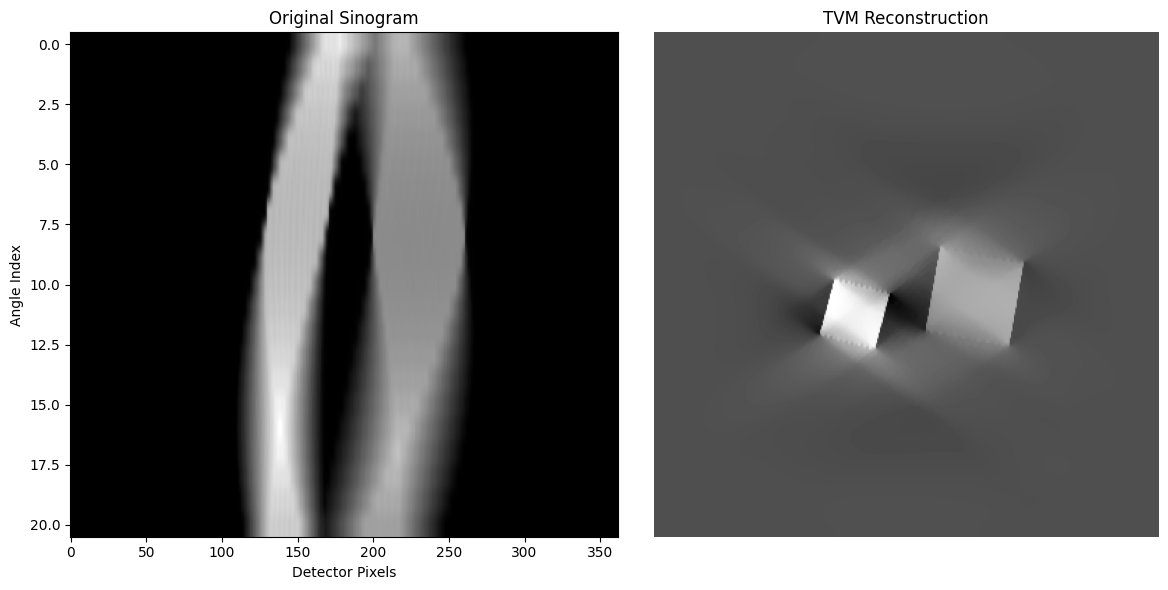

In [4]:
## TVM

import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon_sart
from skimage.restoration import denoise_tv_chambolle

def reconstruct_tvm(input_sinogram_mrc, angles_degrees, output_img_path, num_iterations=100, tv_weight=0.1):
    """
    Reconstructs a 2D tomogram using Total Variation Minimization (SART-TV).
    
    Parameters:
    - num_iterations: Number of SART + TV loops. Higher means better convergence but takes longer.
    - tv_weight: The regularization parameter for Total Variation. 
                 Higher values increase smoothing and reduce noise/artifacts, 
                 but too high will blur structural details.
    """
    print("Loading original 2D sinogram...")
    with mrcfile.open(input_sinogram_mrc, permissive=True) as mrc:
        sinogram = np.squeeze(mrc.data.astype(np.float32))
        voxel_size = mrc.voxel_size

    if len(sinogram.shape) != 2:
        raise ValueError(f"Expected a 2D sinogram, but got shape {sinogram.shape}")

    if sinogram.shape[1] == len(angles_degrees):
        sinogram = sinogram.T  
        
    if sinogram.shape[0] != len(angles_degrees):
        raise ValueError(f"Angle mismatch! Sinogram: {sinogram.shape[0]} rows, Angles: {len(angles_degrees)}")

    print(f"Sinogram shape verified (Angles, Pixels): {sinogram.shape}")

    print(f"\n--- Reconstructing Image via TVM (Iterations: {num_iterations}, TV Weight: {tv_weight}) ---")

    sino_t = sinogram.T
    reconstructed_img = np.zeros((sino_t.shape[0], sino_t.shape[0]), dtype=np.float32)
    
    for i in range(num_iterations):
        reconstructed_img = iradon_sart(sino_t, theta=angles_degrees, image=reconstructed_img)
        reconstructed_img = denoise_tv_chambolle(reconstructed_img, weight=tv_weight)
        if (i + 1) % 5 == 0 or i == 0:
            print(f"Completed iteration {i + 1}/{num_iterations}")

    reconstructed_img = reconstructed_img.astype(np.float32)

    print(f"\nSaving {output_img_path}...")
    with mrcfile.new(output_img_path, overwrite=True) as mrc_out:
        mrc_out.set_data(reconstructed_img)
        mrc_out.voxel_size = voxel_size

    print("Complete! TVM reconstruction successfully generated.")

    return sinogram, reconstructed_img

def view_results(sinogram_data, reconstructed_data):
    print(f"Visualizing - Sinogram shape: {sinogram_data.shape}, Reconstruction shape: {reconstructed_data.shape}")
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(sinogram_data, cmap='gray', aspect='auto')
    axes[0].set_title('Original Sinogram')
    axes[0].set_ylabel('Angle Index')
    axes[0].set_xlabel('Detector Pixels')

    axes[1].imshow(reconstructed_data, cmap='gray')
    axes[1].set_title('TVM Reconstruction')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

my_angles = np.arange(FROM, TO + 1, STEP) 

if not FBP:
    sino, recon = reconstruct_tvm(SINOGRAM_FILE, my_angles, FULL_FBP_FILE, num_iterations=100, tv_weight=0.5)
    view_results(sino, recon)

## STEP 2 - MODEL FITTING

In [5]:
# TRAINING CONFIG

PATCH_SIZE = 96
# Patch size
STRIDES_2D = [3, 3]
# X and Y stride

LR = 1e-5
EPOCHS = 100
BATCH_SIZE = 8
MW_ANGLE = (360-TO*4)/2


In [6]:
# PRE STEP 2 - DATA PREPARATION

import os
from pathlib import Path
from scripts.prepare_data import prepare_data_2d

def run_test():
    print("Starting DeepDeWedge 2D Data Preparation Test...")
    
    if not FULL_FBP_FILE.exists():
        print("\n[ERROR] Input files not found!")
        return

    prepare_data_2d(
    reconstruction_files=[FULL_FBP_FILE],
    patch_size=PATCH_SIZE,
    patch_extraction_strides=STRIDES_2D,
    pad_before_patch_extraction=True,
    standardize_full_reconstructions=True,
    patch_dir=DATA_DIR / "patches",
    overwrite=True
    )
    
    print(f"\nTest complete! Check the '{DATA_DIR}/subtomos' folder to see your extracted .pt files.")

run_test()

Starting DeepDeWedge 2D Data Preparation Test...
Saving all patches to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\patches'.
Removing existing patch directory 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\patches'.
Starting 2D patch extraction from 1 image(s).
Standardizing image 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\full_slice_fbp.mrc'.
Done with patch extraction.
Saved 5336 patches for model fitting to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\patches/fitting_patches'.
Saved 593 patches for validation to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data\patches/val_patches'.

Test complete! Check the 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\data/subtomos' folder to see your extracted .pt files.


In [7]:
# MODEL FITTING
import os
from scripts.fit_model import fit_model_2d


def run_model_fitting():
    print("Starting DeepDeWedge 2D Model Fitting Test...")
    
    unet_params = {
        'in_chans': 1, 
        'out_chans': 1, 
        'num_downsample_layers': 2,
        'chans': 64, 
        'drop_prob': 0.0
    }

    adam_params = {
        'lr': LR
    }

    fit_model_2d(
        unet_params_dict=unet_params,
        adam_params_dict=adam_params,
        num_epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patch_size=PATCH_SIZE,    
        patch_dir=str(DATA_DIR / "patches"),
        mw_angle=MW_ANGLE,
        artificial_mw_angle=30.0,
        
        gpu=[0],
        num_workers=4,
        logdir=str(PROJECT_FOLDER / "logs"),
        check_val_every_n_epochs=1,
        logger="csv"
    )
    
    print(f"\nFitting Test complete! Check the '{PROJECT_FOLDER}/logs' folder for your checkpoints.")

if __name__ == "__main__":
    run_model_fitting()

c:\Users\Alberto\Desktop\Electron tomography\Method_2\tomo_venv\Lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Alberto\Desktop\Electron tomography\Method_2\tomo_venv\Lib\site-packages\lightning_lite\utilities\seed.py:40: UserWarning: No seed found, seed set to 2400431740
  rank_zero_warn(f"No seed found, seed set to {seed}")
Global seed set to 2400431740
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Starting DeepDeWedge 2D Model Fitting Test...
Saving logs and model checkpoints to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw/logs/version_2'


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation DataLoader 0:  16%|█▌        | 12/75 [00:01<00:09,  6.98it/s]

c:\Users\Alberto\Desktop\Electron tomography\Method_2\tomo_venv\Lib\site-packages\pytorch_lightning\utilities\data.py:85: UserWarning: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 8. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
  warning_cache.warn(


...

Epoch 54, global step 36685: 'fitting_loss' reached 4.30013 (best 4.17127), saving model to 'C:\\Users\\Alberto\\Desktop\\Electron tomography\\Method_2\\Project_ddw/logs/version_2/checkpoints/fitting_loss\\epoch=54-fitting_loss=4.30013.ckpt' as top 5
Epoch 54, global step 36685: 'val_loss' reached 7.87751 (best 6.15683), saving model to 'C:\\Users\\Alberto\\Desktop\\Electron tomography\\Method_2\\Project_ddw/logs/version_2/checkpoints/val_loss\\epoch=54-val_loss=7.87751.ckpt' as top 5


Epoch 55: 100%|██████████| 742/742 [02:01<00:00,  6.10it/s, loss=0.168, v_num=2, val_loss=8.410, fitting_loss=4.140]

Epoch 55, global step 37352: 'fitting_loss' reached 4.14149 (best 4.14149), saving model to 'C:\\Users\\Alberto\\Desktop\\Electron tomography\\Method_2\\Project_ddw/logs/version_2/checkpoints/fitting_loss\\epoch=55-fitting_loss=4.14149.ckpt' as top 5
Epoch 55, global step 37352: 'val_loss' was not in top 5


Epoch 56:  30%|███       | 224/742 [00:40<01:34,  5.50it/s, loss=4.76, v_num=2, val_loss=8.410, fitting_loss=4.140] 
Fitting Test complete! Check the 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw/logs' folder for your checkpoints.


c:\Users\Alberto\Desktop\Electron tomography\Method_2\tomo_venv\Lib\site-packages\pytorch_lightning\trainer\call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


C:\Users\Alberto\AppData\Local\Temp\ipykernel_24336\2526322671.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


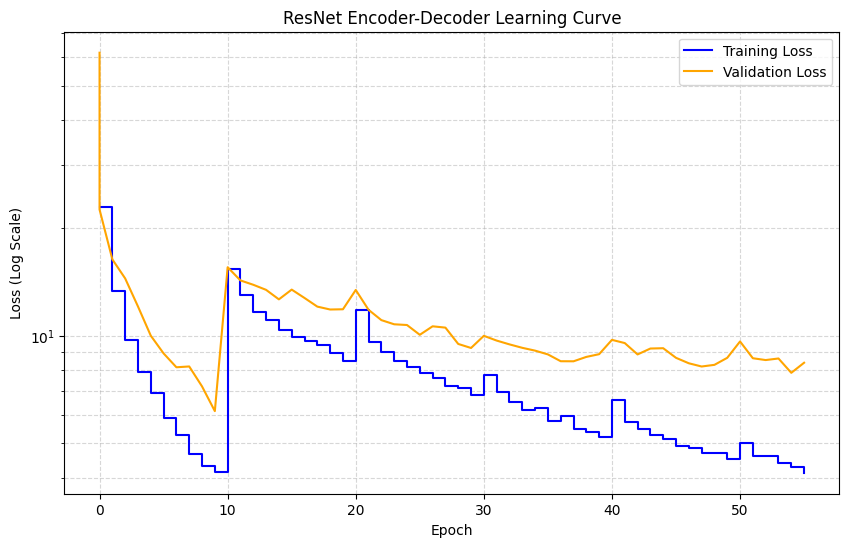

In [9]:
# Plot losses

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Update this path to the correct version folder inside your logs directory
metrics_file = PROJECT_FOLDER / "logs/version_0/metrics.csv"

if metrics_file.exists():
    df = pd.read_csv(metrics_file)
    
    # fill NaN values
    df = df.fillna(method="ffill")
    
    plt.figure(figsize=(10, 6))
    
    # fitting (training) loss
    if "fitting_loss" in df.columns:
        plt.plot(df["epoch"], df["fitting_loss"], label="Training Loss", color="blue")
        
    # validation loss
    if "val_loss" in df.columns:
        plt.plot(df["epoch"], df["val_loss"], label="Validation Loss", color="orange")
        
    plt.title("ResNet Encoder-Decoder Learning Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (Log Scale)")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()
else:
    print(f"Could not find {metrics_file}. Check your version number!")

## STEP 3 - TOMOGRAM REFINEMENT AND VISUALIZATION

In [19]:
from pathlib import Path
from scripts.refine_tomogram import refine_image_2d

def run_test():
    print("Starting Final 2D Tomogram Refinement...")
    
    checkpoint_path = PROJECT_FOLDER / "logs/version_1/checkpoints/val_loss" 
    best_ckpt = list(checkpoint_path.glob("*.ckpt"))[0] if checkpoint_path.exists() else "path/to/your/model.ckpt"
    
    refine_image_2d(
        reconstruction_files=[FULL_FBP_FILE],
        model_checkpoint_file=best_ckpt,
        patch_size=PATCH_SIZE,
        mw_angle=MW_ANGLE,
        patch_overlap=32,
        standardize_full_reconstructions=True,
        batch_size=BATCH_SIZE,
        output_dir=PROJECT_FOLDER / "refined_slices",
        gpu=[0]
    ) 
    
    print(f"\nRefinement Complete! Check '{PROJECT_FOLDER}/refined_slices' for your final image.")

if __name__ == "__main__":
    run_test()

Starting Final 2D Tomogram Refinement...


Refining full_slice_fbp.mrc: 100%|██████████| 5/5 [00:00<00:00, 12.04it/s]

Saving refined image to C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices/full_slice_fbp_refined.mrc
File 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices/full_slice_fbp_refined.mrc' already exists! Moving it to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices/full_slice_fbp_refined.mrc~'

Refinement Complete! Check 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw/refined_slices' for your final image.


In [20]:
REFINED_MRC_PATH = r"C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices\full_slice_fbp_refined.mrc"
OBJECT_AREA_SIZE = 1000

Loading C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices\full_slice_fbp_refined.mrc...
Refined image shape: (362, 362)


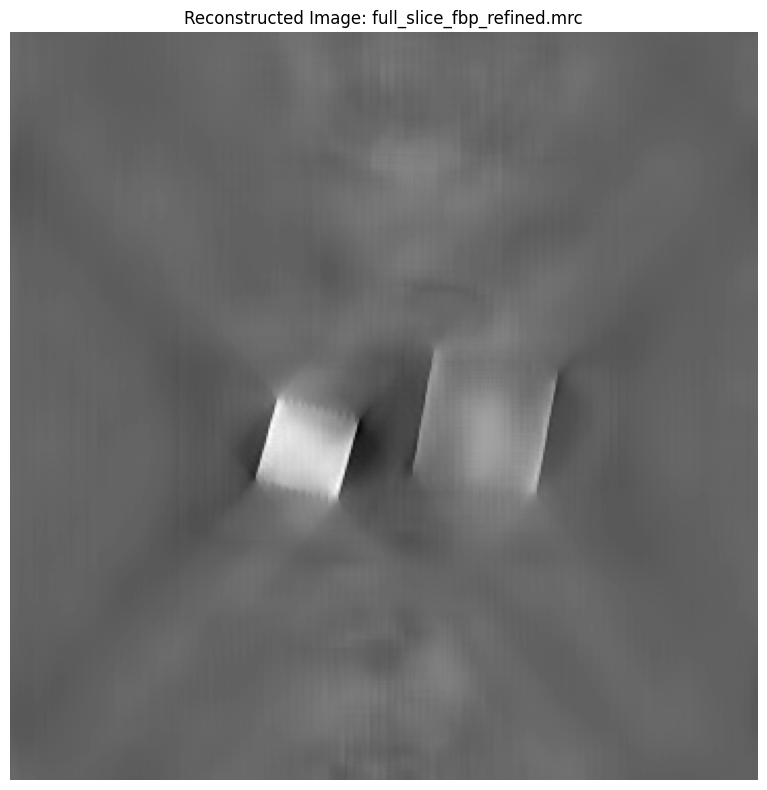

In [21]:
# Show refined image

def view_image(refined_path):
    print(f"Loading {refined_path}...")
    
    with mrcfile.open(refined_path, permissive=True) as mrc:
        img_data = np.squeeze(mrc.data)
        
    print(f"Refined image shape: {img_data.shape}")
        
    plt.figure(figsize=(8, 8))
    plt.imshow(img_data, cmap='gray')
    plt.title(f'Reconstructed Image: {Path(refined_path).name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

view_image(REFINED_MRC_PATH)

### Extra step: Object Contouring and mask extraction

In [67]:
import mrcfile
import numpy as np
import cv2

def convert_mrc_to_png(mrc_path, png_path):
    try:
        with mrcfile.open(mrc_path, permissive=True) as mrc:
            data = mrc.data

        # normalize
        data_min = np.min(data)
        data_max = np.max(data)

        if data_max == data_min:
            normalized_image = np.zeros(data.shape, dtype=np.uint8)
        else:
            # scale values to 0.0 - 1.0, then multiply by 255
            scaled_data = (data - data_min) / (data_max - data_min) * 255.0
            normalized_image = scaled_data.astype(np.uint8)

        cv2.imwrite(png_path, normalized_image)
        print(f"Successfully converted '{mrc_path}' to '{png_path}'")

    except Exception as e:
        print(f"An error occurred during conversion: {e}")


def create_object_mask(image_path, output_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print("Error: Could not load image. Check the path.")
        return

    # Otsu's Thresholding (threshold calculated automatically)
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_mask = np.zeros_like(image)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > OBJECT_AREA_SIZE:
            cv2.drawContours(final_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    cv2.imwrite(output_path, final_mask)
    print(f"Mask successfully saved to {output_path}")


def show_image(image_path, window_name="Image Viewer"):
    image = cv2.imread(image_path)

    if image is None:
        print(f"Error: Could not load image at '{image_path}'. Please check the path.")
        return
    
    cv2.imshow(window_name, image)

    print("Press any key in the image window to close it.")

    cv2.waitKey(0)
    
    cv2.destroyAllWindows()

In [68]:
convert_mrc_to_png(REFINED_MRC_PATH, REFINED_MRC_PATH[:-4] + ".png")

create_object_mask(REFINED_MRC_PATH[:-4] + ".png", REFINED_MRC_PATH[:-4] + "_MASK.png")

show_image(REFINED_MRC_PATH[:-4] + "_MASK.png", 'Mask PNG Image')

Successfully converted 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices\full_slice_fbp_refined.mrc' to 'C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices\full_slice_fbp_refined.png'
Mask successfully saved to C:\Users\Alberto\Desktop\Electron tomography\Method_2\Project_ddw\refined_slices\full_slice_fbp_refined_MASK.png
Press any key in the image window to close it.
